In [1]:
import ltn
print("Contenido de ltn:", [x for x in dir(ltn) if not x.startswith('_')])
if hasattr(ltn, 'core'):
    print("Contenido de ltn.core:", [x for x in dir(ltn.core) if not x.startswith('_')])

Contenido de ltn: ['Constant', 'Function', 'Predicate', 'Proposition', 'Variable', 'Wrapper_Connective', 'Wrapper_Formula_Aggregator', 'Wrapper_Quantifier', 'as_tensors', 'core', 'diag', 'diag_lock', 'fuzzy_ops', 'undiag', 'utils']
Contenido de ltn.core: ['Any', 'Callable', 'Constant', 'Expression', 'FloatTensorLike', 'Formula', 'Function', 'List', 'Optional', 'Predicate', 'Proposition', 'Term', 'Union', 'VarLabel', 'Variable', 'Wrapper_Connective', 'Wrapper_Formula_Aggregator', 'Wrapper_Quantifier', 'annotations', 'as_tensors', 'broadcast_exprs', 'broadcast_wff_and_mask', 'diag', 'diag_lock', 'layers', 'np', 'tf', 'tf_LambdaModel', 'transpose_free_vars', 'undiag', 'warnings']


In [2]:
import ltn.fuzzy_ops
print("Operaciones disponibles en fuzzy_ops:", [x for x in dir(ltn.fuzzy_ops) if not x.startswith('_')])

Operaciones disponibles en fuzzy_ops: ['Aggreg_LogProd', 'Aggreg_Max', 'Aggreg_Mean', 'Aggreg_Min', 'Aggreg_Prod', 'Aggreg_SumLog', 'Aggreg_pMean', 'Aggreg_pMeanError', 'And_Luk', 'And_Min', 'And_Prod', 'Equiv', 'Implies_Godel', 'Implies_Goguen', 'Implies_KleeneDienes', 'Implies_Luk', 'Implies_Reichenbach', 'Not_Godel', 'Not_Std', 'Or_Luk', 'Or_Max', 'Or_ProbSum', 'eps', 'not_ones', 'not_zeros', 'tf', 'warn']


In [3]:
import torch
import ltn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
tf.experimental.numpy.experimental_enable_numpy_behavior()

# Usamos los Wrappers directamente, que son las clases base en LTNtorch
# Si Wrapper_And falla, es que la instalación está corrupta o es una versión muy antigua
# Re-instanciamos los operadores para asegurar que existan en el espacio de nombres
# 1. Definimos los conectivos usando los Wrappers que aparecen en tu ltn.core
# Pasamos la operación lógica desde ltn.fuzzy_ops
# Usamos exactamente los nombres que nos dio la inspección
Not = ltn.Wrapper_Connective(ltn.fuzzy_ops.Not_Std())
And = ltn.Wrapper_Connective(ltn.fuzzy_ops.And_Prod())
Implies = ltn.Wrapper_Connective(ltn.fuzzy_ops.And_Luk()) # O Implies_Luk si lo prefieres

# Para Forall, usamos Aggreg_pMean (fíjate en la 'p' minúscula según tu lista)
Forall = ltn.Wrapper_Formula_Aggregator(ltn.fuzzy_ops.Aggreg_pMean(p=2))

print("¡Operadores lógicos configurados y listos para la acción!")


%matplotlib inline
sns.set_theme(style="whitegrid")

¡Operadores lógicos configurados y listos para la acción!


In [4]:
import os
# Definición de ruta
file_path =  '../../data/raw/dataset_aireado.csv'

if os.path.exists(file_path):
    df_raw = pd.read_csv(file_path)
    print(f"Dataset cargado exitosamente. Formato: {df_raw.shape}")
else:
    print("Error: El archivo no existe en la ruta especificada.")

# Asegurar orden temporal para los lags
df_raw = df_raw.sort_values(['run_id', 'time_min'])

df_raw.head()
df_raw.describe()


Dataset cargado exitosamente. Formato: (30000, 11)


,run_id,time_min,fault_id,Kg_embutido,T_amb,T_set,N_fan_Hz,RH_cab,T_cab,T_evap_sat,P_comp_W
count,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000,30000.0,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,74.50000,99.500000,1.486667,814.753275,21.999547,14.0,38.024406,77.659323,15.104113,5.870932,1006.174408
std,43.30103,57.735267,1.117973,384.209294,0.998749,0.0,16.497485,9.675030,0.627952,2.669044,339.571861
min,0.00000,0.000000,0.000000,207.178752,18.077600,14.0,-1.779119,53.055099,13.128236,-4.808059,191.297967
25%,37.00000,49.750000,0.000000,476.040844,21.322398,14.0,23.994417,74.160451,14.629426,6.119776,740.516320
50%,74.50000,99.500000,1.000000,782.544611,22.002064,14.0,36.958913,76.833016,15.046079,6.802736,990.632475
75%,112.00000,149.250000,2.000000,1182.216480,22.675265,14.0,52.785206,84.893670,15.549646,7.368881,1264.099874
max,149.00000,199.000000,3.000000,1482.953018,26.479084,14.0,78.505367,97.096321,17.184335,9.892296,2023.952782


<Axes: xlabel='RH_cab', ylabel='Count'>

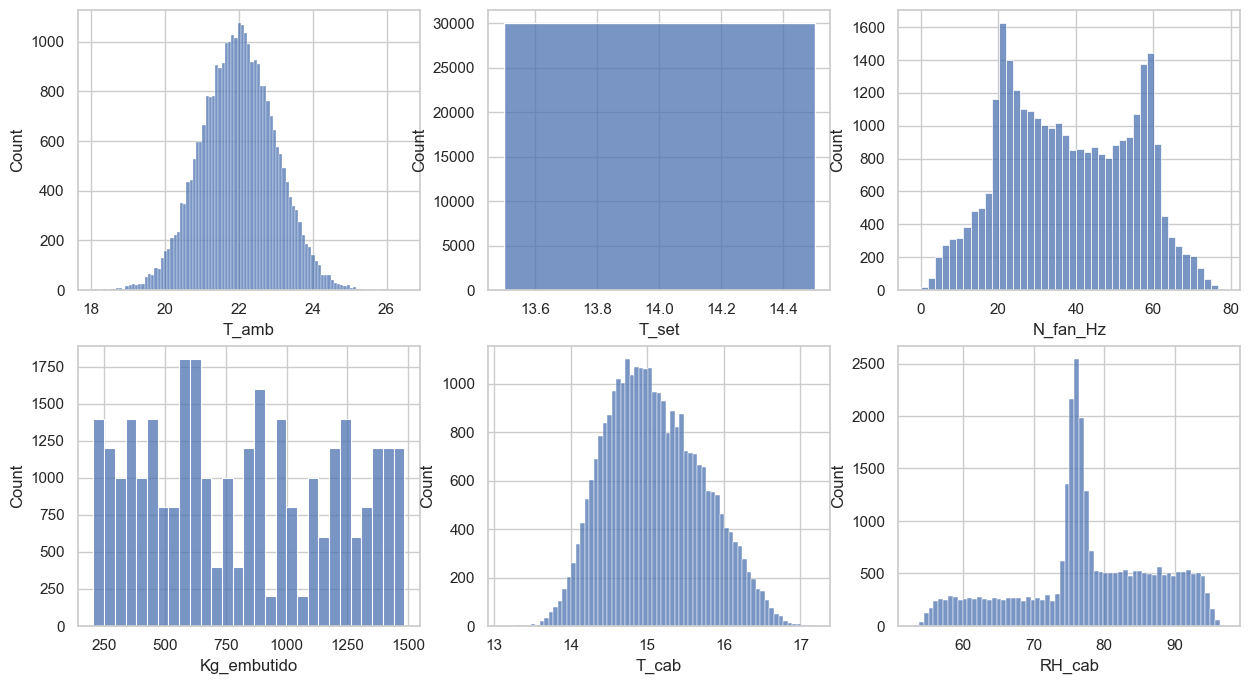

In [5]:
#Distributions of features (with histograms)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sns.histplot(data=df_raw, x='T_amb', ax=axes[0, 0])
sns.histplot(data=df_raw, x='T_set', ax=axes[0, 1])
sns.histplot(data=df_raw, x='N_fan_Hz', ax=axes[0, 2])
sns.histplot(data=df_raw, x='Kg_embutido', ax=axes[1, 0])
sns.histplot(data=df_raw, x='T_cab', ax=axes[1, 1])
sns.histplot(data=df_raw, x='RH_cab',ax=axes[1, 2] )

In [6]:
def extract_aireado_features(df):
    df_ext = df.copy()
    
    # 1. Delta Higroscópico (Referencia: Ruiz-Ramirez, 2005)
    # Diferencia respecto a la humedad de equilibrio teórica
    df_ext['RH_error'] = df_ext['RH_cab'] - 75.0 
    
    # 2. Ratio Aire/Carga (Referencia: Imre, 1974)
    # Evalúa si el flujo de aire es suficiente para la masa de embutido
    df_ext['Air_Flow_Ratio'] = df_ext['N_fan_Hz'] / (df_ext['Kg_embutido'] + 1.0)
    
    # 3. Eficiencia de Evaporación (Referencia: Andrés et al., 2007)
    # Relación entre enfriamiento y deshumidificación
    df_ext['Evap_Eff_Index'] = (df_ext['T_cab'] - df_ext['T_evap_sat']) / (df_ext['RH_cab'] + 0.1)
    
    # 4. Potencia Específica por Carga (Referencia: Toldrá, 2006)
    # Energía consumida por cada Kg de producto fresco
    df_ext['Specific_Power_Load'] = df_ext['P_comp_W'] / (df_ext['Kg_embutido'] + 1.0)
    
    # 5. Indicador de Encostramiento (Predictor de Falla 1)
    # Aire alto + RH baja = Riesgo de Case Hardening
    df_ext['Encostramiento_Risk'] = df_ext['N_fan_Hz'] / (df_ext['RH_cab'] + 1.0)

    return df_ext

df_phys = extract_aireado_features(df_raw)

In [7]:
def inject_test_noise(X_test_df, noise_level):
    """
    Añade ruido gaussiano y picos de error al set de test para simular
    sensores reales de planta.
    """
    X_noisy = X_test_df.copy()
    
    for col in X_noisy.columns:
        # Añadimos ruido gaussiano (fluctuación de señal)
        scale = X_noisy[col].std() * noise_level
        if scale > 0:
            X_noisy[col] += np.random.normal(0, scale, X_noisy.shape[0])
            
        # Añadimos 'Spikes' (1 de cada 100 lecturas falla totalmente)
        mask = np.random.rand(len(X_noisy)) < 0.01
        X_noisy.loc[mask, col] *= np.random.choice([0.8, 1.2]) 
        
    return X_noisy

In [8]:
def create_aireado_lags(df, features, lags):
    df_lagged = df.copy()
    for feat in features:
        for lag in lags:
            # Valor previo del sensor
            df_lagged[f"{feat}_lag_{lag}"] = df_lagged.groupby("run_id")[feat].shift(lag)
            # TENDENCIA: Delta de cambio (Crucial para ver si el secado se estanca)
            df_lagged[f"{feat}_delta_{lag}"] = df_lagged[feat] - df_lagged[f"{feat}_lag_{lag}"]
    
    # Rolling mean para suavizar ciclos de ventilación periódica (Imre, 1974)
    df_lagged['RH_roll_mean_20'] = df_lagged.groupby('run_id')['RH_cab'].transform(lambda x: x.rolling(20, min_periods=5).mean())
    
    return df_lagged

# Aplicamos a variables críticas
features_to_lag = ['RH_cab', 'T_cab', 'N_fan_Hz', 'Evap_Eff_Index']
lags_aireado = [10, 30, 60]

df_final = create_aireado_lags(df_phys, features_to_lag, lags_aireado)

# Limpieza de NaNs generados por lags
df_final = df_final.dropna()
print(f"Dataset final listo para entrenamiento: {df_final.shape}")

Dataset final listo para entrenamiento: (21000, 41)


In [9]:
import tensorflow as tf

# Separación de características y objetivo
target = 'fault_id'
features = [col for col in df_final.columns if col not in ['run_id', 'time_min', 'fault_id']]

# 1. Escalado de datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_final[features])

# 2. Separación por grupos (runs)
unique_runs = df_final['run_id'].unique()
train_runs, test_runs = train_test_split(unique_runs, test_size=0.2, random_state=42)

# --- PREPARACIÓN PARA LTN (TENSORFLOW VERSION) ---

# 3. Datos de Entrenamiento
x_train_np = X_scaled[df_final['run_id'].isin(train_runs)].astype(np.float32)
# En la versión TF de LTN, pasamos los valores directamente como numpy
# La librería se encarga de la diferenciación interna
x_train = ltn.Variable("x", x_train_np)

y_train_np = df_final[df_final['run_id'].isin(train_runs)][target].values
# Convertimos a tensor de TF para las máscaras de la KB
y_train = tf.constant(y_train_np)

# 4. Datos de Test
x_test_np = X_scaled[df_final['run_id'].isin(test_runs)].astype(np.float32)
x_test = ltn.Variable("x", x_test_np)

y_test_np = df_final[df_final['run_id'].isin(test_runs)][target].values
y_test = tf.constant(y_test_np)

print(f"Variables LTN-TF listas. Entrenamiento: {x_train_np.shape}")

Variables LTN-TF listas. Entrenamiento: (16800, 38)


In [10]:

# Modelo de Keras (igual que antes)
model_keras = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(len(features),)),
    tf.keras.layers.Dense(4, activation='softmax')
])

# El predicado ahora solo envuelve al modelo para procesar 'x'
# Ya no le pasaremos la constante de la clase aquí.
es_estado = ltn.Predicate(model_keras)

# Constantes (ajustadas a tu versión que pide trainable)
clases = {i: ltn.Constant(i, trainable=False) for i in range(4)}

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
def knowledge_base(x, y_true):
    preds = model_keras(x.tensor) 
    rules = []
    
    p_mean = ltn.fuzzy_ops.Aggreg_pMean(p=2)
    forall_op = ltn.Wrapper_Quantifier(aggreg_op=p_mean, semantics="forall")
    not_op = ltn.Wrapper_Connective(ltn.fuzzy_ops.Not_Std())

    # 1. REGLAS DE SUPERVISIÓN
    for i in range(4):
        mask = tf.equal(y_true, i)
        if tf.reduce_any(mask):
            prob_correcta = tf.boolean_mask(preds[:, i], mask)
            var_label = f"x_{i}"
            v_obj = ltn.Variable(var_label, prob_correcta)
            f_clase = ltn.core.Formula(v_obj.tensor, [var_label])
            rules.append(forall_op([v_obj], f_clase))

    # 2. REGLA FÍSICA
    hz_idx = features.index('N_fan_Hz')
    mask_hz_bajo = x.tensor[:, hz_idx] < -1.0 
    if tf.reduce_any(mask_hz_bajo):
        prob_normal = tf.boolean_mask(preds[:, 0], mask_hz_bajo)
        v_hz_obj = ltn.Variable("x_hz", prob_normal)
        f_normal = ltn.core.Formula(v_hz_obj.tensor, ["x_hz"])
        f_not_normal = not_op(f_normal)
        rules.append(forall_op([v_hz_obj], f_not_normal))

    # 3. COMBINACIÓN FINAL (Solución al TypeError)
    # Usamos Aggreg_Prod que es matemáticamente equivalente a un AND persistente
    and_aggregator = ltn.Wrapper_Formula_Aggregator(ltn.fuzzy_ops.Aggreg_Prod())
    return and_aggregator(rules)

In [12]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

print("Iniciando entrenamiento neuro-simbólico...")
for epoch in range(201):
    with tf.GradientTape() as tape:
        sat_level = knowledge_base(x_train, y_train)
        loss = 1.0 - sat_level.tensor
        
    gradients = tape.gradient(loss, model_keras.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model_keras.trainable_variables))
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Satisfacción: {sat_level.tensor.numpy():.4f} | Loss: {loss.numpy():.4f}")

Iniciando entrenamiento neuro-simbólico...
Epoch   0 | Satisfacción: 0.0048 | Loss: 0.9952
Epoch  20 | Satisfacción: 0.9138 | Loss: 0.0862
Epoch  40 | Satisfacción: 0.9727 | Loss: 0.0273
Epoch  60 | Satisfacción: 0.9749 | Loss: 0.0251
Epoch  80 | Satisfacción: 0.9752 | Loss: 0.0248
Epoch 100 | Satisfacción: 0.9754 | Loss: 0.0246
Epoch 120 | Satisfacción: 0.9754 | Loss: 0.0246
Epoch 140 | Satisfacción: 0.9755 | Loss: 0.0245
Epoch 160 | Satisfacción: 0.9756 | Loss: 0.0244
Epoch 180 | Satisfacción: 0.9756 | Loss: 0.0244
Epoch 200 | Satisfacción: 0.9756 | Loss: 0.0244


In [13]:
# Celda 10 corregida para TensorFlow
# Pasamos los datos como un tensor de TF
x_test_tensor = tf.constant(x_test_np)

# Obtenemos las probabilidades del modelo
outputs = model_keras(x_test_tensor, training=False)

# Elegimos la clase con mayor probabilidad
y_pred = tf.argmax(outputs, axis=1).numpy()

from sklearn.metrics import classification_report
target_names = ['NORMAL', 'ENCOSTRAMIENTO', 'SATURACIÓN', 'FALLO VENTILADOR']
print(classification_report(y_test_np, y_pred, target_names=target_names))

                  precision    recall  f1-score   support

          NORMAL       1.00      1.00      1.00      1400
  ENCOSTRAMIENTO       1.00      1.00      1.00       980
      SATURACIÓN       1.00      1.00      1.00       980
FALLO VENTILADOR       1.00      1.00      1.00       840

        accuracy                           1.00      4200
       macro avg       1.00      1.00      1.00      4200
    weighted avg       1.00      1.00      1.00      4200

